# Bagging Machine Learning Algorithm

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd

In [2]:
df=sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.dropna(inplace=True)

In [5]:
df.shape

(182, 15)

In [6]:
df['pclass'].unique()

array([1, 3, 2])

In [7]:
df['pclass'].value_counts()

pclass
1    157
2     15
3     10
Name: count, dtype: int64

In [8]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [9]:
df['sex'].value_counts()

sex
male      94
female    88
Name: count, dtype: int64

<Axes: >

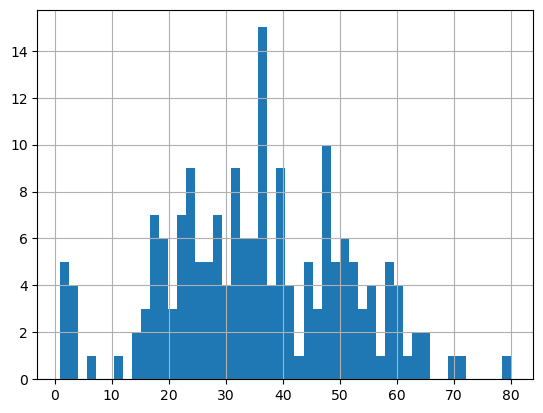

In [10]:
df['age'].hist(bins=50)

## Data Preprocessing

In [11]:
X=df[['pclass','sex','age']].copy()

In [12]:
from sklearn import preprocessing
#lb=preprocessing.LabelBinarizer()
le=preprocessing.LabelEncoder()

In [13]:
X['sex']=le.fit_transform(df['sex'])

In [14]:
X.head()

,pclass,sex,age
1,1,0,38.0
3,1,0,35.0
6,1,1,54.0
10,3,0,4.0
11,1,0,58.0


In [15]:
X.shape

(182, 3)

In [16]:
X.describe()

,pclass,sex,age
count,182.000000,182.000000,182.000000
mean,1.192308,0.516484,35.623187
std,0.516411,0.501107,15.671615
min,1.000000,0.000000,0.920000
25%,1.000000,0.000000,24.000000
50%,1.000000,1.000000,36.000000
75%,1.000000,1.000000,47.750000
max,3.000000,1.000000,80.000000


In [17]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182 entries, 1 to 889
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pclass  182 non-null    int64  
 1   sex     182 non-null    int64  
 2   age     182 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 5.7 KB


In [18]:
y=df['survived'].copy()

In [19]:
y.value_counts()

survived
1    123
0     59
Name: count, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)

In [22]:
from sklearn import preprocessing
from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, roc_auc_score

def print_score(clf, X_train, X_test, y_train, y_test, train=True):
    
    lb = preprocessing.LabelBinarizer()
    lb.fit(y_train)
    
    if train:
        res = clf.predict(X_train)
        print("Train result:\n")
        print("Accuracy score: {0:.4f}\n".format(accuracy_score(y_train, res)))
        print("Classification report:\n{}\n".format(classification_report(y_train, res)))
        print("Confusion matrix:\n{}\n".format(confusion_matrix(y_train, res)))
        print("ROC AUC: {0:.4f}\n".format(
            roc_auc_score(lb.transform(y_train), lb.transform(res))
        ))
        res=cross_val_score(clf,X_train,y_train,cv=10,scoring='accuracy')
        print("Average accuracy :\t{0:.4f}".format(np.mean(res)))
        print("Accuracy SD:\t\t{0:.4f}".format(np.std(res)))
        
    else:
        res_test = clf.predict(X_test)
        print("Test result:\n")
        print("Accuracy score: {0:.4f}\n".format(accuracy_score(y_test, res_test)))
        print("Classification report:\n{}\n".format(classification_report(y_test, res_test)))
        print("Confusion matrix:\n{}\n".format(confusion_matrix(y_test, res_test)))
        print("ROC AUC: {0:.4f}\n".format(
            roc_auc_score(lb.transform(y_test), lb.transform(res_test))
        ))


## Boosting(Hypothesis Boosting)
* Combine several week learners into a strong learner.
*  Train predictors sequently

## AdaBoost/Adaptive Boosting

In [23]:
from sklearn.ensemble import AdaBoostClassifier

In [27]:
ada_clf=AdaBoostClassifier(n_estimators=100,random_state=42)

In [28]:
ada_clf.fit(X_train,y_train)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [29]:
AdaBoostClassifier(algorithm='SAMME.R',estimator=None,learning_rate=1.0,
                   n_estimators=100,random_state=None)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'SAMME.R'
,random_state,None


In [31]:
print_score(ada_clf,X_train,X_test,y_train,y_test,train=True)
print("\n************************")
print_score(ada_clf,X_train,X_test,y_train,y_test,train=False)

Train result:

Accuracy score: 0.8110

Classification report:
              precision    recall  f1-score   support

           0       0.69      0.87      0.77        46
           1       0.91      0.78      0.84        81

    accuracy                           0.81       127
   macro avg       0.80      0.82      0.80       127
weighted avg       0.83      0.81      0.81       127


Confusion matrix:
[[40  6]
 [18 63]]

ROC AUC: 0.8237

Average accuracy :	0.7571
Accuracy SD:		0.1197

************************
Test result:

Accuracy score: 0.7091

Classification report:
              precision    recall  f1-score   support

           0       0.45      1.00      0.62        13
           1       1.00      0.62      0.76        42

    accuracy                           0.71        55
   macro avg       0.72      0.81      0.69        55
weighted avg       0.87      0.71      0.73        55


Confusion matrix:
[[13  0]
 [16 26]]

ROC AUC: 0.8095



## AdaBoost with Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
ada_clf=AdaBoostClassifier(RandomForestClassifier(n_estimators=100),n_estimators=100)

In [35]:
ada_clf.fit(X_train,y_train)

,estimator,RandomForestClassifier()
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [36]:
print_score(ada_clf,X_train,X_test,y_train,y_test,train=True)
print("\n************************")
print_score(ada_clf,X_train,X_test,y_train,y_test,train=False)

Train result:

Accuracy score: 0.9528

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93        46
           1       0.94      0.99      0.96        81

    accuracy                           0.95       127
   macro avg       0.96      0.94      0.95       127
weighted avg       0.95      0.95      0.95       127


Confusion matrix:
[[41  5]
 [ 1 80]]

ROC AUC: 0.9395

Average accuracy :	0.7731
Accuracy SD:		0.1341

************************
Test result:

Accuracy score: 0.8364

Classification report:
              precision    recall  f1-score   support

           0       0.59      1.00      0.74        13
           1       1.00      0.79      0.88        42

    accuracy                           0.84        55
   macro avg       0.80      0.89      0.81        55
weighted avg       0.90      0.84      0.85        55


Confusion matrix:
[[13  0]
 [ 9 33]]

ROC AUC: 0.8929



## Gradient Boosting/Gradient Boosting Machine(GBM)

In [38]:
from sklearn.ensemble import GradientBoostingClassifier

In [39]:
gbc_clf=GradientBoostingClassifier()
gbc_clf.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [40]:
print_score(gbc_clf,X_train,X_test,y_train,y_test,train=True)
print("\n************************")
print_score(gbc_clf,X_train,X_test,y_train,y_test,train=False)

Train result:

Accuracy score: 0.9528

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93        46
           1       0.94      0.99      0.96        81

    accuracy                           0.95       127
   macro avg       0.96      0.94      0.95       127
weighted avg       0.95      0.95      0.95       127


Confusion matrix:
[[41  5]
 [ 1 80]]

ROC AUC: 0.9395

Average accuracy :	0.7891
Accuracy SD:		0.1177

************************
Test result:

Accuracy score: 0.8364

Classification report:
              precision    recall  f1-score   support

           0       0.59      1.00      0.74        13
           1       1.00      0.79      0.88        42

    accuracy                           0.84        55
   macro avg       0.80      0.89      0.81        55
weighted avg       0.90      0.84      0.85        55


Confusion matrix:
[[13  0]
 [ 9 33]]

ROC AUC: 0.8929

